### PREDICTION HEART ATTACK WITH USE RANDOM FOREST ALGORITHM
1. age
2. sex
3. chest pain type (4 values)
4. resting blood pressure
5. serum cholestoral in mg/dl
6. fasting blood sugar > 120 mg/dl
7. resting electrocardiographic results (values 0,1,2)
8. maximum heart rate achieved
9. exercise induced angina
10. oldpeak = ST depression induced by exercise relative to rest
11. the slope of the peak exercise ST segment
12. number of major vessels (0-3) colored by flourosopy
13. thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
14. target

#### Data Collection

In [1]:
import pandas as pd

df = pd.read_csv(r"D:\heart attack-ML project\server\dataset\heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [3]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


#### Data Preprocessing

In [4]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(723)

In [6]:
df_clean = df.drop_duplicates(keep='first')
df_clean.shape

(302, 14)

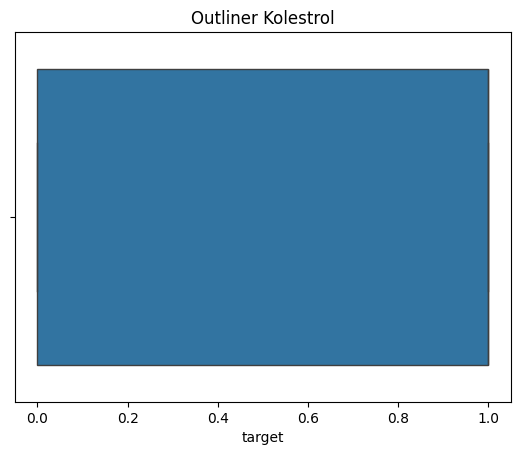

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.Figure(figsize=(20, 4))
sns.boxplot(x=df_clean['target'])
plt.title("Outliner Kolestrol")
plt.show()

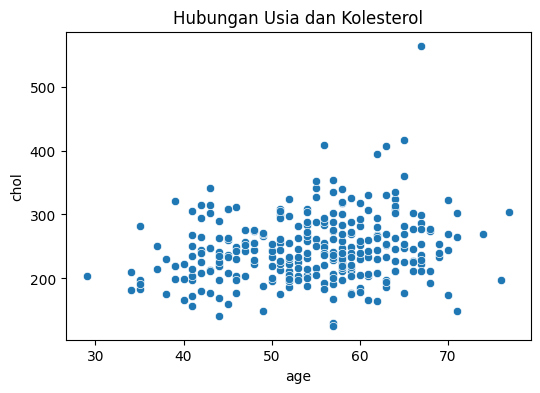

In [8]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='age', y='chol', data=df_clean)
plt.title('Hubungan Usia dan Kolesterol')
plt.show()

In [9]:
df_clean = df_clean[df_clean['chol'] < 500]
df_clean = df_clean[df_clean['thal'] > 0]
df_clean = df_clean[df_clean['ca'] <= 3]
df_clean.shape

(295, 14)

#### Model Training

Akurasi Model Saat Ini: 0.75


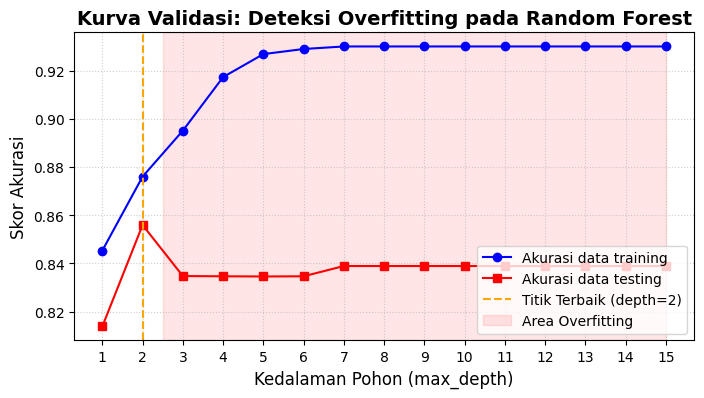

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -- Pisahin Fitur (x) dan Target (y)
x = df_clean.drop(columns=['target'])
y = df_clean['target']

# -- PERBAIKAN URUTAN VARIABEL: train dulu baru test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# -- Buat objek model
model_rf = RandomForestClassifier(
    random_state=42, 
    n_estimators=100,
    min_samples_leaf=4,
    min_samples_split=10,
    max_depth=2,
    class_weight="balanced"
)

# -- Proses belajar
model_rf.fit(x_train, y_train)

# -- Evaluasi model
y_pred = model_rf.predict(x_test)

# -- Skor akurasi
acc = accuracy_score(y_true=y_test, y_pred=y_pred)
print(f"Akurasi Model Saat Ini: {acc:.2f}")

# -- Validation Curve
param_range = np.arange(1, 16)

train_scores, test_scores = validation_curve(
    model_rf,
    x_train, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Menghitung nilai rata-rata
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# -- PERBAIKAN GRAFIK: plt.figure (f kecil) dan marker (pake r)
plt.figure(figsize=(8, 4))
plt.plot(param_range, train_mean, label="Akurasi data training", color="blue", marker="o")
plt.plot(param_range, test_mean, label="Akurasi data testing", color="red", marker="s")

best_depth = param_range[np.argmax(test_mean)]
plt.axvline(x=best_depth, color="orange", linestyle="--", label=f"Titik Terbaik (depth={best_depth})")

# Menandai Area Overfitting secara visual jika melewati titik terbaik
plt.axvspan(best_depth + 0.5, 15, color='red', alpha=0.1, label="Area Overfitting")

plt.title("Kurva Validasi: Deteksi Overfitting pada Random Forest", fontsize=14, fontweight='bold')
plt.xlabel("Kedalaman Pohon (max_depth)", fontsize=12)
plt.ylabel("Skor Akurasi", fontsize=12)
plt.xticks(param_range)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

# Tampilkan Grafik
plt.show()


Akurasi Model: 74.58%

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.75      0.67      0.71        27
           1       0.74      0.81      0.78        32

    accuracy                           0.75        59
   macro avg       0.75      0.74      0.74        59
weighted avg       0.75      0.75      0.74        59



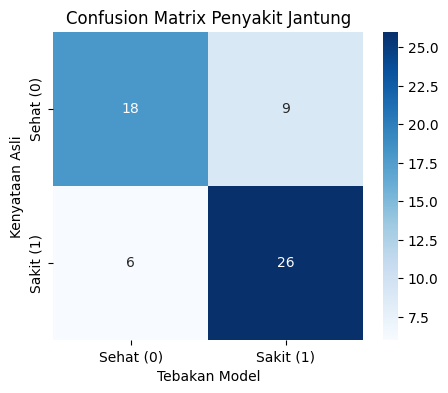

In [11]:
print(f"\nAkurasi Model: {acc * 100:.2f}%")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sehat (0)', 'Sakit (1)'], 
            yticklabels=['Sehat (0)', 'Sakit (1)'])
plt.xlabel('Tebakan Model')
plt.ylabel('Kenyataan Asli')
plt.title('Confusion Matrix Penyakit Jantung')
plt.show()

In [13]:
import os
import joblib

target_dir = os.path.join('..', 'model')

if not os.path.exists(target_dir):
    os.makedirs(target_dir)

joblib.dump(model_rf, os.path.join(target_dir, "model_heart_attack_prediction.pkl"))
print("Model berhasil di simpan")

Model berhasil di simpan
